# Political Fairness Audit

Extension of the *Moral Frame Preserving News Summarization* paper (Bondielli et al., COLM 2025) into a political-fairness analysis.

**Goal:** check whether the paper's prompting methods (Plain / Direct / CoT / Oracle / Class) preserve moral framing *equally* across left-, center-, and right-leaning news articles, and whether the gap depends on the prompting strategy.

**Data:** the AllSides subset of EMONA, where every article filename encodes its political leaning (`allsides_<topic>_<l|c|r>_<n>`). The paper ran three models (Llama-3-70B, CommandR-Plus, DeepSeek-R1-Distill-Qwen-32B) on **180 AllSides articles each** (60 left / 60 center / 60 right, across 12 topics).

This notebook focuses on Llama-3-70B for the deep dive; cross-model comparison is a follow-up.

All data is loaded into in-memory DataFrames -- no CSV side-effects.

## 0. Imports
All required libraries.

In [1]:
import sys
from pathlib import Path
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as stats
from statsmodels.stats.multitest import multipletests

## 1. Load the data

`data_loader.py` lives in the repo root. It pulls the three precomputed metric pickles in `results/automated_evaluation/`, normalizes the `QaFactEval`/`QAFactEval` key inconsistency, drops the `mean`/`std` summary rows, deduplicates rows that appear in more than one pickle (preferring the larger-coverage source), and parses topic/leaning out of the AllSides article IDs.

In [2]:
# Make sure we can import data_loader.py from the repo root.
REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from data_loader import (
    build_full_long,
    build_wide_by_method,
    allsides_only,
    summary_counts,
    PROMPTING_METHODS,
    PAPER_NAME_MAP,
)

# Set global options for Pandas and Seaborn
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)


In [3]:
# Build the master long-format and wide-format DataFrames once.
long_df = build_full_long()
wide_df = build_wide_by_method(long_df)

print(f"long_df: {len(long_df):,} rows  -- one row per (model, article, prompting_method, metric)")
print(f"wide_df: {len(wide_df):,} rows  -- one row per (model, article, metric); prompting methods are columns")

long_df: 50,000 rows  -- one row per (model, article, prompting_method, metric)
wide_df: 8,114 rows  -- one row per (model, article, metric); prompting methods are columns


## 2. Sanity check: counts per leaning

We expect **180 AllSides articles per model**, balanced 60 left / 60 center / 60 right.

In [4]:
summary_counts(long_df)

leaning,model,center,left,right
0,DeepSeek-R1-Distill-Qwen-32B,60,60,60
1,Meta-Llama-3-70B-Instruct,60,60,60
2,c4ai-command-r-plus-4bit,60,60,60
3,llama3.1-8b-instruct-q4_K_M,60,60,60


### Topic x leaning breakdown

EMONA-AllSides is a fully balanced factorial: 12 topics x 3 leanings x 5 replicate articles.

In [5]:
topic_breakdown = (
    allsides_only(long_df)
    .query("model == 'Meta-Llama-3-70B-Instruct' and metric == 'moral_count' and prompting_method == 'vanilla'")
    .groupby(["topic", "leaning"]).size()
    .unstack("leaning", fill_value=0)
)
topic_breakdown

leaning,center,left,right
topic,,,
abortion,5,5,5
coronavirus,5,5,5
elections,5,5,5
gun_control_and_gun_rights,5,5,5
immigration,5,5,5
lgbt_rights,5,5,5
politics,5,5,5
race_and_racism,5,5,5
us_house,5,5,5


## 3. First peek: mean moral_count by leaning x method (Llama)

Raw moral-word retention by political leaning. This is **not** the retention rate yet -- it's the absolute count of moral words preserved in the summary. Left-leaning articles may simply contain more moral language to begin with, which would show up as a higher absolute count even under fair preservation.

We'll convert to a proper retention rate (`moral_count / original`) in the next notebook.

In [6]:
llama_moral_count = (
    allsides_only(long_df)
    .query("model == 'Meta-Llama-3-70B-Instruct' and metric == 'moral_count'")
    .query("prompting_method in @PROMPTING_METHODS")
)

peek = (
    llama_moral_count
    .groupby(["leaning", "prompting_method"])["value"]
    .mean()
    .unstack("prompting_method")
    .round(2)
    # Reorder columns into the paper's naming order: Plain, Direct, CoT, Oracle, Class
    [PROMPTING_METHODS]
    .rename(columns=PAPER_NAME_MAP)
)
peek

prompting_method,Plain,Direct,CoT,Oracle,Class
leaning,,,,,
center,6.48,6.99,7.92,10.86,10.04
left,7.85,8.40,9.19,12.86,11.13
right,7.54,8.27,9.07,12.14,8.67


Also handy: the per-article original (source) moral-word count, by leaning. This tells us whether left/center/right articles differ in baseline moral density.

In [7]:
original_moral_density = (
    allsides_only(long_df)
    .query("model == 'Meta-Llama-3-70B-Instruct' and metric == 'moral_count' and prompting_method == 'original'")
    .groupby("leaning")["value"]
    .agg(["mean", "std", "count"])
    .round(2)
)
original_moral_density

,mean,std,count
leaning,,,
center,21.53,10.63,60
left,27.82,12.99,60
right,23.72,12.80,60


## 4. Statistical Analysis Preprocessing
Here we pivot the metrics so `moral_count` and `moral_div` are columns, and filter out any datasets missing political leaning (like MPQA).

In [8]:
# Pivot the metrics into columns (long_df was already built above!)
df_pivoted = long_df.pivot_table(
    index=['model', 'dataset', 'article', 'leaning', 'prompting_method'],
    columns='metric',
    values='value',
    aggfunc='first'
).reset_index()

df = df_pivoted

# Drop rows where leaning is missing (e.g., MPQA dataset)
df = df.dropna(subset=['leaning'])

# Drop 'original' prompting_method since it represents the baseline article
df_summaries = df[df['prompting_method'] != 'original']
df_summaries.head()

metric,model,dataset,article,leaning,prompting_method,BLANC,QAFactEval,length,moral_count,moral_div,summaC
0,DeepSeek-R1-Distill-Qwen-32B,allsides,allsides_abortion_c_1,center,cot,0.14,2.81,152.0,3.5,0.37,0.34
1,DeepSeek-R1-Distill-Qwen-32B,allsides,allsides_abortion_c_1,center,oracle,0.14,3.00,156.0,11.6,0.10,0.32
3,DeepSeek-R1-Distill-Qwen-32B,allsides,allsides_abortion_c_1,center,simple,0.17,3.23,181.8,6.0,0.26,0.35
4,DeepSeek-R1-Distill-Qwen-32B,allsides,allsides_abortion_c_1,center,vanilla,0.15,3.12,171.2,4.4,0.33,0.40
5,DeepSeek-R1-Distill-Qwen-32B,allsides,allsides_abortion_c_2,center,class,0.12,3.25,187.2,13.0,0.20,0.30


## 5. Descriptive Statistics
Let's look at the basic averages (mean) and standard deviations (std) for moral preservation across each strategy and ideology.

In [9]:
stats_summary = df_summaries.groupby(['prompting_method', 'leaning'])[['moral_count', 'moral_div']].agg(['mean', 'std', 'count']).round(3)
display(stats_summary)

metric                     moral_count              moral_div             
                                  mean    std count      mean    std count
prompting_method   leaning                                                
class              center        9.749  5.092    43     0.240  0.147    42
                   left         10.830  2.595    33     0.179  0.052    33
                   right         8.440  2.569    30     0.194  0.088    30
cot                center        7.538  3.545   230     0.246  0.115   227
                   left          8.957  3.628   230     0.222  0.080   225
                   right         8.599  3.701   227     0.209  0.082   224
cot_fewshot        center        6.930  3.584    50     0.269  0.133    50
                   left          8.240  3.348    50     0.224  0.089    50
                   right         8.021  3.458    47     0.214  0.093    47
cot_fewshot_mft    center        6.800  4.051    50     0.281  0.156    50
                   left          8.460  3.530    50     0.222  0.094    50
                   right         7.809  3.449    47     0.214  0.101    47
oracle             center       10.735  4.194   217     0.182  0.086   217
                   left         12.780  4.812   208     0.173  0.072   208
                   right        11.632  4.394   197     0.160  0.066   197
simple             center        6.638  3.378   230     0.257  0.118   217
                   left          7.945  3.277   230     0.238  0.076   226
                   right         7.507  3.612   227     0.230  0.092   222
simple_fewshot     center        6.320  3.377    50     0.272  0.138    48
                   left          7.930  3.648    50     0.229  0.080    49
                   right         7.351  3.929    47     0.226  0.112    44
simple_fewshot_mft center        6.380  3.428    50     0.272  0.156    49
                   left          7.980  3.825    50     0.233  0.088    49
                   right         7.638  3.767    47     0.229  0.131    45
vanilla            center        6.143  3.264   230     0.276  0.127   218
                   left          7.458  3.226   230     0.242  0.085   225
                   right         6.992  3.349   226     0.237  0.102   222

## 6. Kruskal-Wallis & Mann-Whitney U Tests (Moral Count)
**Goal:** Check if the AI model treats Left, Center, and Right articles differently when preserving moral words.
- **Kruskal-Wallis:** Tells us if there is *any* difference across the 3 groups.
- **Mann-Whitney U:** If a difference exists, this tells us *which* specific groups (e.g. Left vs Right) are different.

In [10]:
print("Non-Parametric Tests for: moral_count")
from statsmodels.stats.multitest import multipletests

# Separate the data by leaning
left   = df_summaries[df_summaries['leaning'] == 'left']['moral_count'].dropna()
center = df_summaries[df_summaries['leaning'] == 'center']['moral_count'].dropna()
right  = df_summaries[df_summaries['leaning'] == 'right']['moral_count'].dropna()

# 1. Kruskal-Wallis H-test
h_stat, p_val = stats.kruskal(left, center, right)
print(f"Kruskal-Wallis H-statistic: {h_stat:.3f}, p-value: {p_val:.3e}")

if p_val < 0.05:
    print("\n-> Significant difference found across ideologies! "
          "Proceeding with Mann-Whitney U pairwise tests (Bonferroni-corrected):\n")

    # 2. Mann-Whitney U tests – collect raw p-values first
    u_lc, p_lc = stats.mannwhitneyu(left,   center, alternative='two-sided')
    u_cr, p_cr = stats.mannwhitneyu(center,  right,  alternative='two-sided')
    u_lr, p_lr = stats.mannwhitneyu(left,    right,  alternative='two-sided')

    # 3. Bonferroni correction for 3 simultaneous comparisons
    raw_pvals = [p_lc, p_cr, p_lr]
    reject, pvals_bonf, _, _ = multipletests(raw_pvals, method='bonferroni')

    pairs = [
        ('Left',   'Center', u_lc),
        ('Center', 'Right',  u_cr),
        ('Left',   'Right',  u_lr),
    ]
    header = f"   {'Comparison':<22} {'U-stat':>10} {'p (raw)':>12} {'p (Bonf.)':>12} {'Sig.':>6}"
    print(header)
    print("   " + "-" * 64)
    for (a, b, u), p_raw, p_corr, sig in zip(pairs, raw_pvals, pvals_bonf, reject):
        label = f"{a} vs {b}"
        print(f"   {label:<22} {u:>10.1f} {p_raw:>12.3e} {p_corr:>12.3e} {'*' if sig else 'ns':>6}")
else:
    print("\n-> No significant difference found across ideologies.")

Non-Parametric Tests for: moral_count
Kruskal-Wallis H-statistic: 69.339, p-value: 8.774e-16

-> Significant difference found across ideologies! Proceeding with Mann-Whitney U pairwise tests (Bonferroni-corrected):

   Comparison                 U-stat      p (raw)    p (Bonf.)   Sig.
   ----------------------------------------------------------------
   Left vs Center           780605.0    1.179e-16    3.536e-16      *
   Center vs Right          556259.0    1.756e-06    5.267e-06      *
   Left vs Right            671207.0    6.043e-04    1.813e-03      *


## 6b. Kruskal-Wallis & Mann-Whitney U Tests (Moral Divergence)
**Goal:** Check if the AI model treats Left, Center, and Right articles differently when preserving the moral distribution (divergence).
- **Kruskal-Wallis:** Tells us if there is *any* difference across the 3 groups.
- **Mann-Whitney U:** If a difference exists, this tells us *which* specific groups (e.g. Left vs Right) are different.

In [11]:
print("Non-Parametric Tests for: moral_div")


# Separate the data by leaning
left   = df_summaries[df_summaries['leaning'] == 'left']['moral_div'].dropna()
center = df_summaries[df_summaries['leaning'] == 'center']['moral_div'].dropna()
right  = df_summaries[df_summaries['leaning'] == 'right']['moral_div'].dropna()

# 1. Kruskal-Wallis H-test
h_stat, p_val = stats.kruskal(left, center, right)
print(f"Kruskal-Wallis H-statistic: {h_stat:.3f}, p-value: {p_val:.3e}")

if p_val < 0.05:
    print("\n-> Significant difference found across ideologies! "
          "Proceeding with Mann-Whitney U pairwise tests (Bonferroni-corrected):\n")

    # 2. Mann-Whitney U tests – collect raw p-values first
    u_lc, p_lc = stats.mannwhitneyu(left,   center, alternative='two-sided')
    u_cr, p_cr = stats.mannwhitneyu(center,  right,  alternative='two-sided')
    u_lr, p_lr = stats.mannwhitneyu(left,    right,  alternative='two-sided')

    # 3. Bonferroni correction for 3 simultaneous comparisons
    raw_pvals = [p_lc, p_cr, p_lr]
    reject, pvals_bonf, _, _ = multipletests(raw_pvals, method='bonferroni')

    pairs = [
        ('Left',   'Center', u_lc),
        ('Center', 'Right',  u_cr),
        ('Left',   'Right',  u_lr),
    ]
    header = f"   {'Comparison':<22} {'U-stat':>10} {'p (raw)':>12} {'p (Bonf.)':>12} {'Sig.':>6}"
    print(header)
    print("   " + "-" * 64)
    for (a, b, u), p_raw, p_corr, sig in zip(pairs, raw_pvals, pvals_bonf, reject):
        label = f"{a} vs {b}"
        print(f"   {label:<22} {u:>10.1f} {p_raw:>12.3e} {p_corr:>12.3e} {'*' if sig else 'ns':>6}")
else:
    print("\n-> No significant difference found across ideologies.")

Non-Parametric Tests for: moral_div
Kruskal-Wallis H-statistic: 48.165, p-value: 3.476e-11

-> Significant difference found across ideologies! Proceeding with Mann-Whitney U pairwise tests (Bonferroni-corrected):

   Comparison                 U-stat      p (raw)    p (Bonf.)   Sig.
   ----------------------------------------------------------------
   Left vs Center           560217.5    3.441e-05    1.032e-04      *
   Center vs Right          701734.5    2.440e-11    7.320e-11      *
   Left vs Right            649593.0    1.034e-03    3.103e-03      *


## 7. Few-Shot vs 0-Shot (Moral Count)
**Goal:** Compare each of the four balanced few-shot strategies against the vanilla zero-shot baseline using a paired Wilcoxon Signed-Rank test on `moral_count`.

Strategies tested: `simple_fewshot`, `cot_fewshot`, `simple_fewshot_mft`, `cot_fewshot_mft`.

In [12]:
print("=" * 60)
print("Wilcoxon Signed-Rank Tests: Few-Shot vs Vanilla (Moral Count)")
print("=" * 60)

few_shot_strategies = [
    'simple_fewshot',
    'cot_fewshot',
    'simple_fewshot_mft',
    'cot_fewshot_mft',
]
baseline_strategy = 'vanilla'

baseline_data = (
    df_summaries[df_summaries['prompting_method'] == baseline_strategy]
    .set_index(['model', 'dataset', 'article'])
)

for strategy in few_shot_strategies:
    print(f"\n--- {strategy} vs {baseline_strategy} ---")

    dynamic_data = (
        df_summaries[df_summaries['prompting_method'] == strategy]
        .set_index(['model', 'dataset', 'article'])
    )

    if dynamic_data.empty:
        print(f"  WARNING: '{strategy}' not found in data. "
              "Make sure the new pickle file is loaded.")
        continue

    common_idx = baseline_data.index.intersection(dynamic_data.index)
    if len(common_idx) == 0:
        print("  No overlapping articles found.")
        continue

    paired = pd.concat(
        [dynamic_data.loc[common_idx, 'moral_count'],
         baseline_data.loc[common_idx, 'moral_count']],
        axis=1,
    ).dropna()

    if len(paired) == 0:
        print("  Not enough paired data (after dropping NaNs).")
        continue

    stat, p_val = stats.wilcoxon(paired.iloc[:, 0], paired.iloc[:, 1])
    print(f"  Paired samples : {len(paired)}")
    print(f"  W-statistic    : {stat:.1f}")
    print(f"  p-value        : {p_val:.3e}")
    if p_val < 0.05:
        print(f"  -> Significant difference detected.")
    else:
        print(f"  -> No significant difference.")

Wilcoxon Signed-Rank Tests: Few-Shot vs Vanilla (Moral Count)

--- simple_fewshot vs vanilla ---
  Paired samples : 146
  W-statistic    : 3685.5
  p-value        : 3.608e-01
  -> No significant difference.

--- cot_fewshot vs vanilla ---
  Paired samples : 146
  W-statistic    : 2700.0
  p-value        : 1.849e-04
  -> Significant difference detected.

--- simple_fewshot_mft vs vanilla ---
  Paired samples : 146
  W-statistic    : 2507.0
  p-value        : 1.777e-01
  -> No significant difference.

--- cot_fewshot_mft vs vanilla ---
  Paired samples : 146
  W-statistic    : 2472.5
  p-value        : 3.384e-03
  -> Significant difference detected.


## 7b. Few-Shot vs 0-Shot (Moral Divergence)
**Goal:** Same paired comparison as above, but on the `moral_div` (Jensen-Shannon divergence) metric.

Strategies tested: `simple_fewshot`, `cot_fewshot`, `simple_fewshot_mft`, `cot_fewshot_mft`.

In [13]:
print("=" * 60)
print("Wilcoxon Signed-Rank Tests: Few-Shot vs Vanilla (Moral Divergence)")
print("=" * 60)

few_shot_strategies = [
    'simple_fewshot',
    'cot_fewshot',
    'simple_fewshot_mft',
    'cot_fewshot_mft',
]
baseline_strategy = 'vanilla'

baseline_data = (
    df_summaries[df_summaries['prompting_method'] == baseline_strategy]
    .set_index(['model', 'dataset', 'article'])
)

for strategy in few_shot_strategies:
    print(f"\n--- {strategy} vs {baseline_strategy} ---")

    dynamic_data = (
        df_summaries[df_summaries['prompting_method'] == strategy]
        .set_index(['model', 'dataset', 'article'])
    )

    if dynamic_data.empty:
        print(f"  WARNING: '{strategy}' not found in data. "
              "Make sure the new pickle file is loaded.")
        continue

    common_idx = baseline_data.index.intersection(dynamic_data.index)
    if len(common_idx) == 0:
        print("  No overlapping articles found.")
        continue

    paired = pd.concat(
        [dynamic_data.loc[common_idx, 'moral_div'],
         baseline_data.loc[common_idx, 'moral_div']],
        axis=1,
    ).dropna()

    if len(paired) == 0:
        print("  Not enough paired data (after dropping NaNs).")
        continue

    stat, p_val = stats.wilcoxon(paired.iloc[:, 0], paired.iloc[:, 1])
    print(f"  Paired samples : {len(paired)}")
    print(f"  W-statistic    : {stat:.1f}")
    print(f"  p-value        : {p_val:.3e}")
    if p_val < 0.05:
        print(f"  -> Significant difference detected.")
    else:
        print(f"  -> No significant difference.")

Wilcoxon Signed-Rank Tests: Few-Shot vs Vanilla (Moral Divergence)

--- simple_fewshot vs vanilla ---
  Paired samples : 141
  W-statistic    : 3745.5
  p-value        : 3.628e-01
  -> No significant difference.

--- cot_fewshot vs vanilla ---
  Paired samples : 144
  W-statistic    : 3610.0
  p-value        : 2.279e-02
  -> Significant difference detected.

--- simple_fewshot_mft vs vanilla ---
  Paired samples : 142
  W-statistic    : 3496.0
  p-value        : 4.236e-01
  -> No significant difference.

--- cot_fewshot_mft vs vanilla ---
  Paired samples : 144
  W-statistic    : 3226.5
  p-value        : 1.058e-01
  -> No significant difference.


## 8. Visualizations
These figures are designed specifically to demonstrate political bias (or fairness).

### 8.1. Trend Analysis (Pointplot)
This plot clearly shows if the average moral count shifts across ideologies. 

/var/folders/ch/qym_61v94419d_l_l6jz80f00000gn/T/ipykernel_78404/1918246283.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=10)


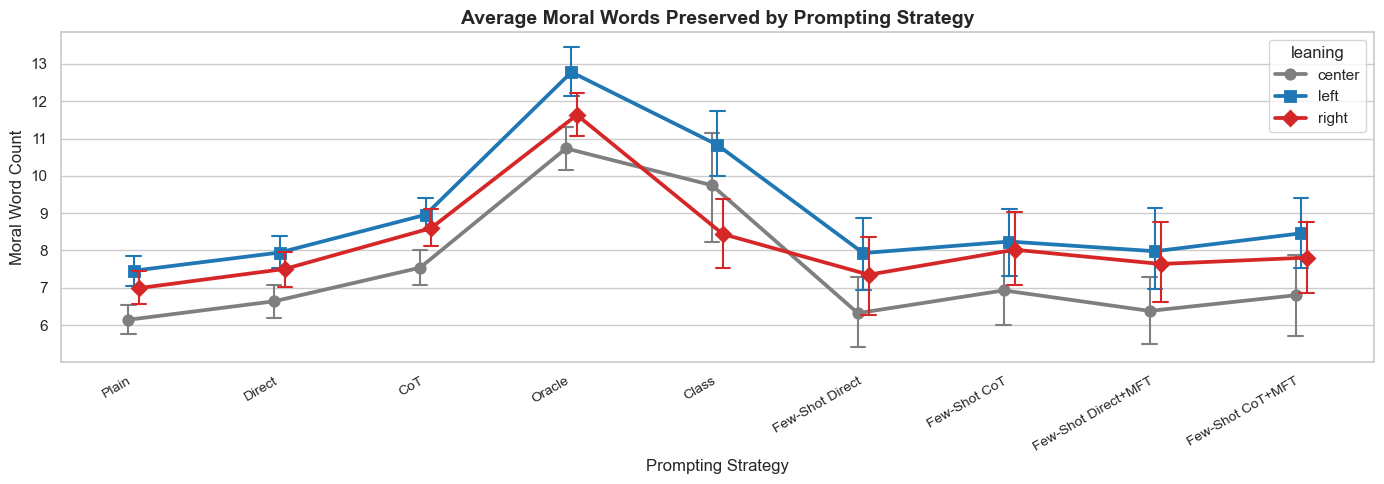

In [14]:
sns.set_theme(style="whitegrid", palette="muted")
ideology_colors = {'left': '#1f77b4', 'center': '#7f7f7f', 'right': '#d62728'}

if 'moral_count' in df_summaries.columns:
    from data_loader import ALL_PROMPTING_METHODS, PAPER_NAME_MAP

    # Map method codes to paper names for display
    plot_df = df_summaries.copy()
    plot_df['Strategy'] = plot_df['prompting_method'].map(PAPER_NAME_MAP).fillna(plot_df['prompting_method'])
    strategy_order = [PAPER_NAME_MAP.get(m, m) for m in ALL_PROMPTING_METHODS if m in plot_df['prompting_method'].values]

    fig, ax = plt.subplots(figsize=(14, 5))
    sns.pointplot(
        data=plot_df,
        x='Strategy',
        y='moral_count',
        hue='leaning',
        palette=ideology_colors,
        order=strategy_order,
        dodge=True,
        markers=['o', 's', 'D'],
        capsize=.1,
        err_kws={'linewidth': 1.5},
        ax=ax
    )
    ax.set_title('Average Moral Words Preserved by Prompting Strategy', fontsize=14, fontweight='bold')
    ax.set_xlabel('Prompting Strategy', fontsize=12)
    ax.set_ylabel('Moral Word Count', fontsize=12)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=10)
    plt.tight_layout()
    plt.savefig('fig1_moral_count_trend.png', dpi=300, bbox_inches='tight')
    plt.show()

### 8.2. Moral Retention Rate (% of Original)
This calculates exactly what percentage of the *original* article's moral words were preserved by the AI (e.g. 1.0 = kept 100%). If fair, all three bars should be perfectly level.

/var/folders/ch/qym_61v94419d_l_l6jz80f00000gn/T/ipykernel_78404/3068584365.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=10)


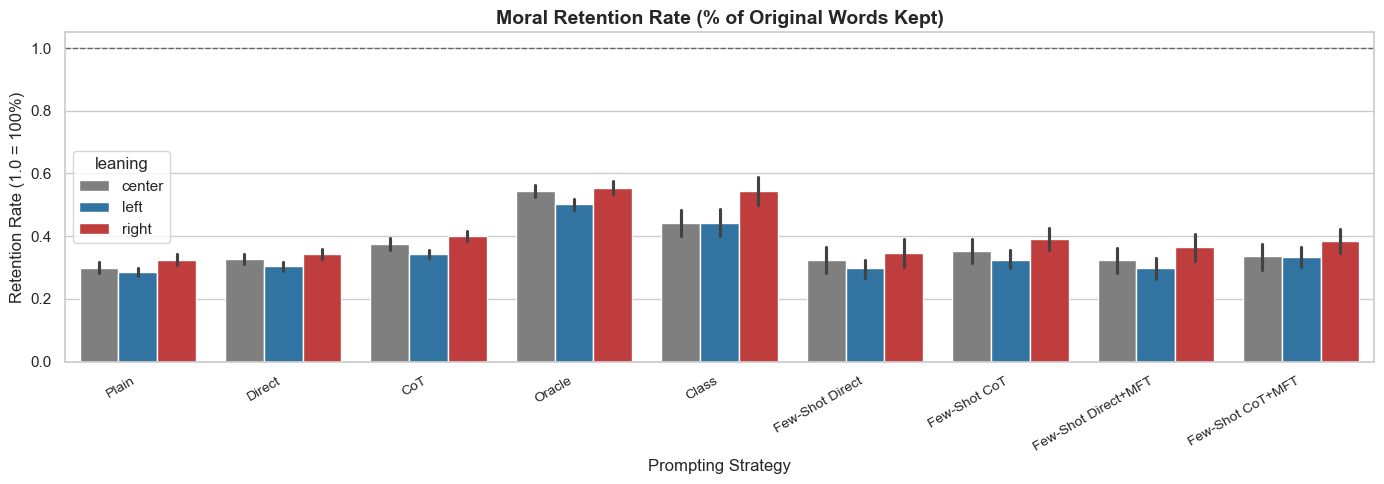

In [15]:
if 'wide_df' in globals():
    from data_loader import ALL_PROMPTING_METHODS, PAPER_NAME_MAP

    # Filter for moral count metric
    retention_df = wide_df[wide_df['metric'] == 'moral_count'].copy()
    retention_df = retention_df.dropna(subset=['leaning'])

    melted_retention = []
    # Use ALL_PROMPTING_METHODS so new few-shot strategies are included automatically
    methods_to_plot = [m for m in ALL_PROMPTING_METHODS if m in retention_df.columns]

    for method in methods_to_plot:
        temp = retention_df[['article', 'leaning', 'original', method]].copy()
        temp = temp.dropna(subset=[method])          # skip rows with no summary for this method
        if temp.empty:
            continue
        # Avoid division by zero
        temp['retention_rate'] = temp[method] / temp['original'].replace(0, 1)
        temp['Strategy'] = PAPER_NAME_MAP.get(method, method)
        melted_retention.append(temp)

    if melted_retention:
        final_retention = pd.concat(melted_retention).reset_index(drop=True)
        strategy_order = [PAPER_NAME_MAP.get(m, m) for m in ALL_PROMPTING_METHODS
                          if PAPER_NAME_MAP.get(m, m) in final_retention['Strategy'].values]

        fig, ax = plt.subplots(figsize=(14, 5))
        sns.barplot(
            data=final_retention,
            x='Strategy',
            y='retention_rate',
            hue='leaning',
            palette=ideology_colors,
            order=strategy_order,
            ax=ax
        )
        ax.set_title('Moral Retention Rate (% of Original Words Kept)', fontsize=14, fontweight='bold')
        ax.set_xlabel('Prompting Strategy', fontsize=12)
        ax.set_ylabel('Retention Rate (1.0 = 100%)', fontsize=12)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=10)
        ax.axhline(1.0, color='black', linestyle='--', linewidth=1, alpha=0.5)  # 100% reference line
        plt.tight_layout()
        plt.savefig('fig2_moral_retention_rate.png', dpi=300, bbox_inches='tight')
        plt.show()

### 8.3. Distribution of Moral Divergence (Violin Plot)
This shows how much the moral tone shifted overall (Jensen-Shannon Divergence).

/var/folders/ch/qym_61v94419d_l_l6jz80f00000gn/T/ipykernel_78404/1316575490.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=10)


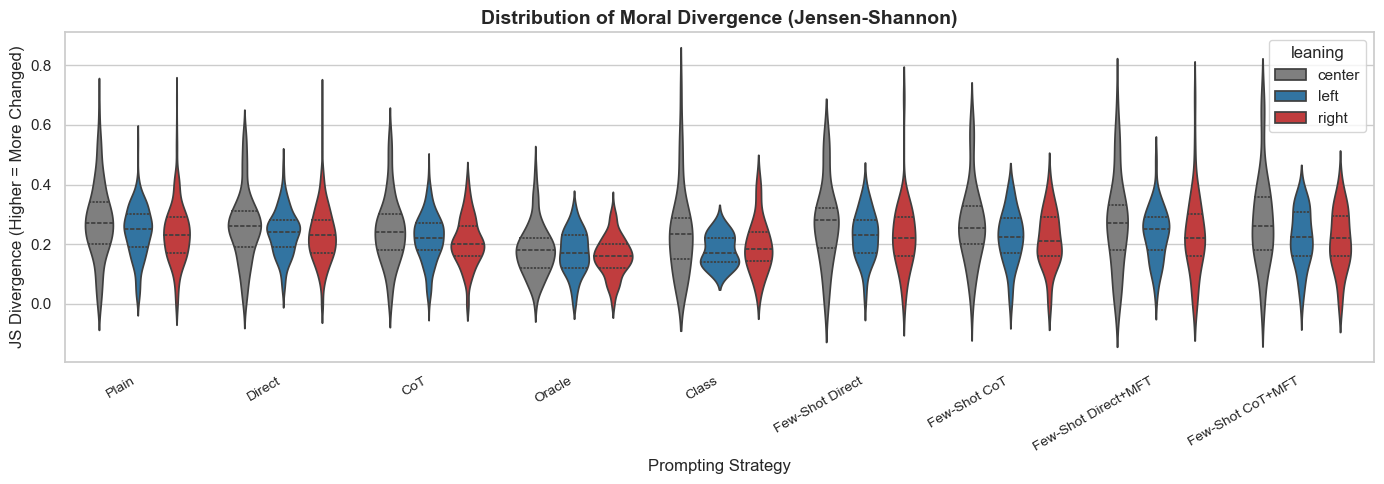

In [16]:
if 'moral_div' in df_summaries.columns:
    from data_loader import ALL_PROMPTING_METHODS, PAPER_NAME_MAP

    plot_df = df_summaries.copy()
    plot_df['Strategy'] = plot_df['prompting_method'].map(PAPER_NAME_MAP).fillna(plot_df['prompting_method'])
    strategy_order = [PAPER_NAME_MAP.get(m, m) for m in ALL_PROMPTING_METHODS if m in plot_df['prompting_method'].values]

    fig, ax = plt.subplots(figsize=(14, 5))
    sns.violinplot(
        data=plot_df,
        x='Strategy',
        y='moral_div',
        hue='leaning',
        palette=ideology_colors,
        order=strategy_order,
        split=False,
        inner="quartile",
        ax=ax
    )
    ax.set_title('Distribution of Moral Divergence (Jensen-Shannon)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Prompting Strategy', fontsize=12)
    ax.set_ylabel('JS Divergence (Higher = More Changed)', fontsize=12)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=10)
    plt.tight_layout()
    plt.savefig('fig3_moral_divergence_violin.png', dpi=300, bbox_inches='tight')
    plt.show()

### 8.4. Ideology Differences Significance (Mann-Whitney U)
This figure graphs the pairwise Mann-Whitney U test results from earlier in the notebook. It proves whether the differences in moral count between Left, Center, and Right articles are mathematically significant across the board. We plot the **-log10(p-value)** so taller bars indicate stronger statistical proof of bias. The red line marks the `p=0.05` significance threshold.

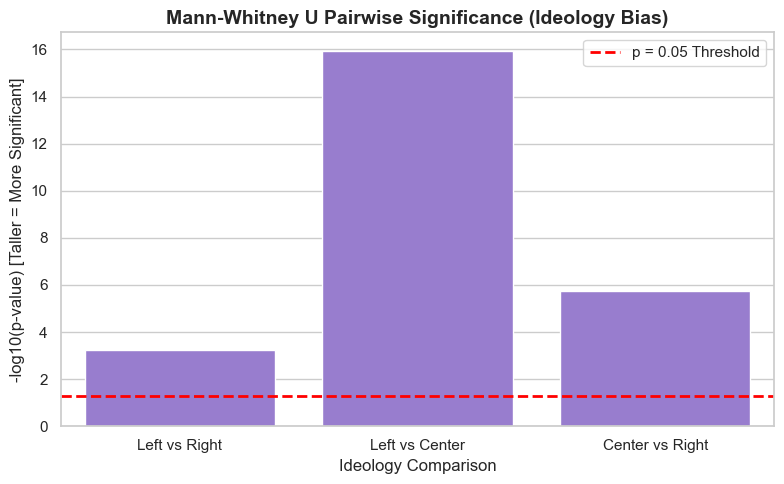

In [17]:
if 'moral_count' in df_summaries.columns:
    left = df_summaries[df_summaries['leaning'] == 'left']['moral_count'].dropna()
    center = df_summaries[df_summaries['leaning'] == 'center']['moral_count'].dropna()
    right = df_summaries[df_summaries['leaning'] == 'right']['moral_count'].dropna()
    
    # Calculate pairwise MWU p-values
    pairs = [
        ('Left vs Right', left, right),
        ('Left vs Center', left, center),
        ('Center vs Right', center, right)
    ]
    
    p_values = []
    labels = []
    
    for label, data1, data2 in pairs:
        if len(data1) > 0 and len(data2) > 0:
            stat, p_val = stats.mannwhitneyu(data1, data2, alternative='two-sided')
            p_values.append(p_val)
            labels.append(label)
            
    if p_values:
        log_p_values = -np.log10(np.array(p_values) + 1e-300)
        
        plt.figure(figsize=(8, 5))
        sns.barplot(x=labels, y=log_p_values, color='#9370db') 
        
        threshold = -np.log10(0.05)
        plt.axhline(threshold, color='red', linestyle='--', linewidth=2, label='p = 0.05 Threshold')
        
        plt.title('Mann-Whitney U Pairwise Significance (Ideology Bias)', fontsize=14, fontweight='bold')
        plt.ylabel('-log10(p-value) [Taller = More Significant]', fontsize=12)
        plt.xlabel('Ideology Comparison', fontsize=12)
        plt.legend()
        plt.tight_layout()
        plt.savefig('fig5_ideology_significance.png', dpi=300)
        plt.show()
    else:
        print("Not enough data to compute pairwise significance.")


## 9. MFT Foundation-Level Breakdown

**Goal:** Check whether specific Moral Foundations Theory (MFT) dimensions are preserved
asymmetrically across political leanings.

We use `moral_framing_extractor.py` — a standalone module that re-reads the same raw
annotation JSONs and model response `.txt` files without touching `eval.py`.
It returns a word-level DataFrame (`mft_df`) where each row is one moral word from an
article, annotated with its MFT foundation, and a `preserved` flag indicating whether
that word appeared in the model's summary.

**MFT foundations covered:** Care/Harm · Fairness/Cheating · Loyalty/Betrayal · Authority/Subversion · Purity/Degradation

In [18]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from moral_framing_extractor import build_posthoc_dfs

mft_df, add_df = build_posthoc_dfs(verbose=True)
print(f"\nmft_df : {len(mft_df):,} rows | add_df : {len(add_df):,} rows")

  [1/180] allsides_abortion_c_1
No END OF SUMMARY token found in response /Users/irenepanteli/Desktop/NLP4Society/moral-summarization-nlp4society/results/test_prompts/allsides/allsides_abortion_c_1/llama3.1-8b-instruct-q4_K_M_cot_fewshot_response.txt
No SUMMARY token found in response /Users/irenepanteli/Desktop/NLP4Society/moral-summarization-nlp4society/results/test_prompts/allsides/allsides_abortion_c_1/llama3.1-8b-instruct-q4_K_M_cot_response.txt
No END OF SUMMARY token found in response /Users/irenepanteli/Desktop/NLP4Society/moral-summarization-nlp4society/results/test_prompts/allsides/allsides_abortion_c_1/llama3.1-8b-instruct-q4_K_M_simple_response.txt
No END OF SUMMARY token found in response /Users/irenepanteli/Desktop/NLP4Society/moral-summarization-nlp4society/results/test_prompts/allsides/allsides_abortion_c_3/llama3.1-8b-instruct-q4_K_M_cot_fewshot_mft_response.txt
No END OF SUMMARY token found in response /Users/irenepanteli/Desktop/NLP4Society/moral-summarization-nlp4so

### 9.1 Preservation Rate by Foundation × Leaning

Mean proportion of moral words that survived into the summary,
broken down by MFT foundation and political leaning.
Rows are foundations; columns are leanings. Values closer to 1 = better preservation.

In [19]:
import pandas as pd

# Preservation rate = mean of the boolean 'preserved' column
pres_table = (
    mft_df
    .groupby(['foundation', 'leaning'])['preserved']
    .mean()
    .unstack('leaning')
    .round(3)
    [['left', 'center', 'right']]   # fix column order
)
# Add a delta column: max - min across leanings (asymmetry signal)
pres_table['max_gap'] = pres_table.max(axis=1) - pres_table.min(axis=1)
display(pres_table.sort_values('max_gap', ascending=False))

leaning,left,center,right,max_gap
foundation,,,,
Purity/Degradation,0.125,0.472,0.423,0.347
Loyalty/Betrayal,0.297,0.202,0.372,0.170
Authority/Subversion,0.310,0.315,0.347,0.037
Fairness/Cheating,0.319,0.340,0.340,0.021
Care/Harm,0.336,0.344,0.337,0.008


### 9.2 Heatmap: Preservation Rate by Foundation × Leaning

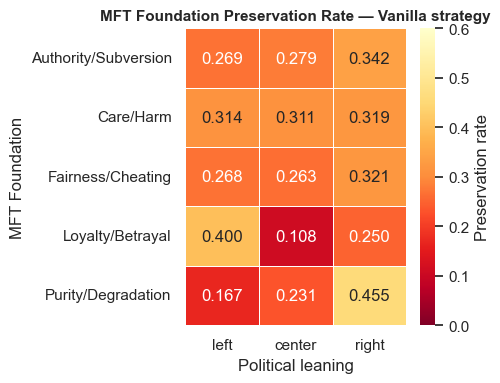

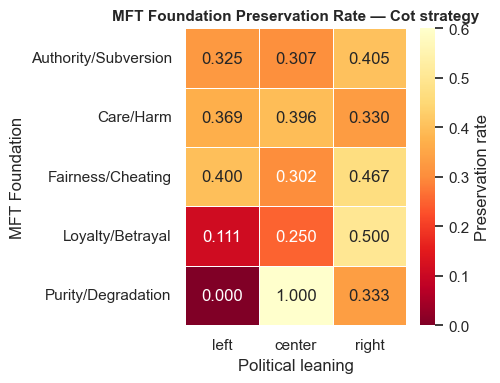

In [20]:
# Per-method heatmap for vanilla (plain baseline)
for method_name in ['vanilla', 'cot']:
    sub = mft_df[mft_df['method'] == method_name]
    if sub.empty:
        continue
    heat = (
        sub.groupby(['foundation', 'leaning'])['preserved']
        .mean()
        .unstack('leaning')
        .round(3)
    )
    # reorder columns if present
    cols = [c for c in ['left', 'center', 'right'] if c in heat.columns]
    heat = heat[cols]

    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(
        heat, annot=True, fmt='.3f', cmap='YlOrRd_r',
        vmin=0, vmax=0.6, ax=ax,
        linewidths=0.5, cbar_kws={'label': 'Preservation rate'}
    )
    ax.set_title(f'MFT Foundation Preservation Rate — {method_name.capitalize()} strategy',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Political leaning')
    ax.set_ylabel('MFT Foundation')
    plt.tight_layout()
    plt.savefig(f'fig_mft_foundation_heatmap_{method_name}.png', dpi=150, bbox_inches='tight')
    plt.show()

### 9.3 Statistical Test: Is Any Foundation Preserved Asymmetrically?

For each MFT foundation we run a Kruskal-Wallis test across the three leaning groups,
then apply Bonferroni correction for 5 simultaneous tests (one per foundation).

In [21]:
foundations = mft_df['foundation'].unique()

results = []
for found in sorted(foundations):
    sub = mft_df[mft_df['foundation'] == found]
    groups = [
        sub[sub['leaning'] == lean]['preserved'].astype(float)
        for lean in ['left', 'center', 'right']
    ]
    groups = [g for g in groups if len(g) > 0]
    if len(groups) < 2:
        continue
    h, p = stats.kruskal(*groups)
    results.append({'Foundation': found, 'H-stat': round(h, 3), 'p (raw)': p})

kw_df = pd.DataFrame(results)
reject, pvals_bonf, _, _ = multipletests(kw_df['p (raw)'], method='bonferroni')
kw_df['p (Bonf.)'] = pvals_bonf.round(4)
kw_df['Significant?'] = reject
display(kw_df.sort_values('p (raw)').reset_index(drop=True))

,Foundation,H-stat,p (raw),p (Bonf.),Significant?
0,Purity/Degradation,14.814,0.000607,0.0030,True
1,Loyalty/Betrayal,13.821,0.000997,0.0050,True
2,Authority/Subversion,9.789,0.007487,0.0374,True
3,Fairness/Cheating,4.293,0.116868,0.5843,False
4,Care/Harm,0.463,0.793312,1.0000,False


## 10. Moral Framing Addition Analysis

**Goal:** Does the model *add* moral language that was not present in the original article,
and does this happen more for articles of a particular political leaning?

A **moral framing addition** occurs when a word in the summary is a known EMONA moral word
(i.e. it appears as a moral annotation in *any* AllSides article) but was **not** annotated
as moral in *this* article. We build a global moral vocabulary from all AllSides annotations
and use it to flag such additions.

In [22]:
import sys, os
from pathlib import Path

# Ensure the repo root is on sys.path so moral_summarization is importable
REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from moral_summarization.data_utils import (
    load_annotations, get_moral_annotations, EMONA_dataset_path
)
from moral_summarization.utils import lemmatize_and_clean

# build a global AllSides moral vocabulary
ann_dir = os.path.join(EMONA_dataset_path, 'moral_allsides_annotations')
global_moral_vocab = {}  # word -> mft_label (first occurrence wins)

for fname in os.listdir(ann_dir):
    article_id = fname.replace('.json', '')
    try:
        anns = load_annotations(article_id, 'allsides')
        for ann in get_moral_annotations(anns):
            w = lemmatize_and_clean(ann['token'])
            if w and w not in global_moral_vocab:
                global_moral_vocab[w] = ann['label']
    except Exception:
        pass

print(f"Global AllSides moral vocabulary: {len(global_moral_vocab):,} unique lemmatized words")

#filter add_df to words in the global vocabulary
from moral_framing_extractor import FOUNDATION_MAP, POLARITY_MAP

add_moral = add_df[add_df['word'].isin(global_moral_vocab)].copy()
add_moral['mft_label']  = add_moral['word'].map(global_moral_vocab)
add_moral['foundation'] = add_moral['mft_label'].map(FOUNDATION_MAP)
add_moral['polarity']   = add_moral['mft_label'].map(POLARITY_MAP)

print(f"Confirmed moral additions: {len(add_moral):,} rows")

Global AllSides moral vocabulary: 1,851 unique lemmatized words
Confirmed moral additions: 27,905 rows


### 10.1 Mean Moral Word Additions per Summary, by Leaning × Method

In [23]:
# Count additions per (article, model, method) then average by leaning
addition_counts = (
    add_moral
    .groupby(['article', 'leaning', 'model', 'method'])['word']
    .count()
    .reset_index(name='n_added')
)

add_summary = (
    addition_counts
    .groupby(['method', 'leaning'])['n_added']
    .mean()
    .unstack('leaning')
    .round(2)
    [[c for c in ['left', 'center', 'right']]]
)
# delta column
add_summary['max_gap'] = add_summary.max(axis=1) - add_summary.min(axis=1)
display(add_summary.sort_values('max_gap', ascending=False))

leaning,left,center,right,max_gap
method,,,,
class,27.83,30.50,23.00,7.50
oracle,30.54,28.27,26.29,4.25
cot,25.04,23.17,25.25,2.08
simple,29.40,28.19,27.35,2.05
simple_fewshot_mft,31.26,31.82,30.06,1.76
simple_fewshot,27.02,26.98,25.60,1.42
cot_fewshot,24.80,25.14,23.85,1.29
vanilla,27.98,27.20,26.83,1.15
cot_fewshot_mft,25.10,25.94,26.19,1.09


### 10.2 Statistical Test: Do Additions Differ by Leaning?

Kruskal-Wallis on the per-summary moral addition count, across leanings.
Bonferroni-corrected Mann-Whitney U if significant.

In [24]:
left_add   = addition_counts[addition_counts['leaning'] == 'left']['n_added']
center_add = addition_counts[addition_counts['leaning'] == 'center']['n_added']
right_add  = addition_counts[addition_counts['leaning'] == 'right']['n_added']

h_add, p_add = stats.kruskal(left_add, center_add, right_add)
print(f"Kruskal-Wallis (moral additions ~ leaning)")
print(f"  H = {h_add:.3f},  p = {p_add:.3e}")

if p_add < 0.05:
    print("\n-> Significant! Running Bonferroni-corrected pairwise tests...\n")
    u_lc, p_lc = stats.mannwhitneyu(left_add, center_add, alternative='two-sided')
    u_cr, p_cr = stats.mannwhitneyu(center_add, right_add,  alternative='two-sided')
    u_lr, p_lr = stats.mannwhitneyu(left_add,  right_add,  alternative='two-sided')
    reject, pvals_bonf, _, _ = multipletests([p_lc, p_cr, p_lr], method='bonferroni')
    pairs = [('Left', 'Center', u_lc), ('Center', 'Right', u_cr), ('Left', 'Right', u_lr)]
    print(f"   {'Comparison':<22} {'U-stat':>10} {'p (raw)':>12} {'p (Bonf.)':>12} {'Sig.':>6}")
    print("   " + '-' * 64)
    for (a, b, u), p_raw, p_corr, sig in zip(pairs, [p_lc,p_cr,p_lr], pvals_bonf, reject):
        print(f"   {a+' vs '+b:<22} {u:>10.1f} {p_raw:>12.3e} {p_corr:>12.3e} {'*' if sig else 'ns':>6}")
else:
    print("-> No significant difference in moral word additions across leanings.")

Kruskal-Wallis (moral additions ~ leaning)
  H = 7.586,  p = 2.252e-02

-> Significant! Running Bonferroni-corrected pairwise tests...

   Comparison                 U-stat      p (raw)    p (Bonf.)   Sig.
   ----------------------------------------------------------------
   Left vs Center            67554.5    4.957e-01    1.000e+00     ns
   Center vs Right           61498.0    3.824e-02    1.147e-01     ns
   Left vs Right             59146.5    8.293e-03    2.488e-02      *


### 10.3 Which MFT Foundations Are Being Added, and for Which Leaning?

Grouped bar chart: proportion of moral word additions that belong to each foundation,
split by political leaning.

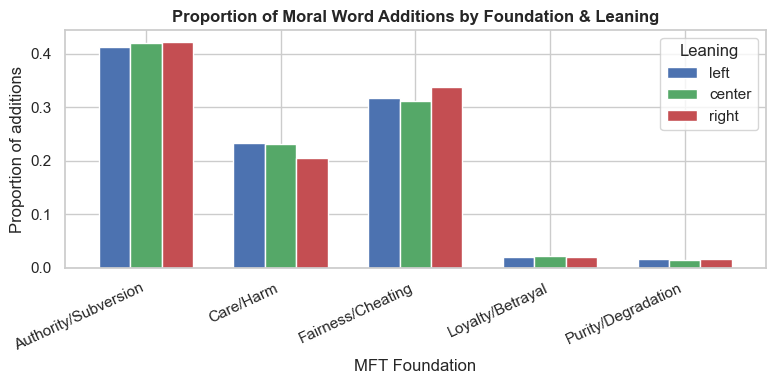

leaning,left,center,right
foundation,,,
Authority/Subversion,0.413,0.419,0.422
Care/Harm,0.233,0.232,0.206
Fairness/Cheating,0.317,0.311,0.337
Loyalty/Betrayal,0.021,0.023,0.020
Purity/Degradation,0.016,0.014,0.016


In [25]:
import numpy as np

found_lean = (
    add_moral
    .groupby(['foundation', 'leaning'])['word']
    .count()
    .unstack('leaning', fill_value=0)
)
# normalise each leaning column to proportions
found_lean_pct = found_lean.div(found_lean.sum(axis=0), axis=1).round(3)

cols = [c for c in ['left', 'center', 'right'] if c in found_lean_pct.columns]
found_lean_pct = found_lean_pct[cols]

ax = found_lean_pct.plot(
    kind='bar', figsize=(8, 4), width=0.7,
    color=['#4C72B0', '#55A868', '#C44E52'],
)
ax.set_title('Proportion of Moral Word Additions by Foundation & Leaning',
             fontweight='bold')
ax.set_xlabel('MFT Foundation')
ax.set_ylabel('Proportion of additions')
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right')
ax.legend(title='Leaning')
plt.tight_layout()
plt.savefig('fig_moral_additions_by_foundation.png', dpi=150, bbox_inches='tight')
plt.show()
display(found_lean_pct)